Vigtigste ændringer:

- bruger pooled healthy training data T1/T2/T3
- vælger PCA-komponenter efter fx 90% forklaret varians
- vælger DPCA-komponenter efter 90% forklaret varians
- skifter thresholds fra 95% til 99%
- laver tosidet Shewhart-limit
- Shewhart evalueres kun én gang, efter fault/test data er transformeret med samme preprocessor som training data
- fjerner case-specifikt sensorvalg i Shewhart, så evalueringen ikke bruger fault-viden
- beholder train/test separation med preprocessor.transform() på fault data
- bruger stadig dine korrekte PCA/DPCA transform- og statistikfunktioner


# FDDES Project 2026

This is the main working file of the project. Here, we review the computations done in "fdd/...". This acts as the main pipeline (imports and runs preprocessing, fd-methods, evaluation, etc).   

## Faulty cases - Ground truth
We know the start and end times of the faults in the different cases which serves as a ground truth to compare the results with.

In [1]:
SEfc1_1 = [1566, 5181] # Fault start and end for FaultyCase1 set 1.1
SEfc1_2 = [657, 3777]
SEfc1_3 = [691, 3691]

SEfc2_1 = [2244, 6616]
SEfc2_2 = [476, 2656]
SEfc2_3 = [331, 2467]

SEfc3_1 = [1136, 8352]
SEfc3_2 = [333, 5871]
SEfc3_3 = [596, 9566]

SEfc4_1 = [953, 6294]
SEfc4_2 = [851, 3851]
SEfc4_3 = [241, 3241]

SEfc5_1 = [686, 1172, 1772, 2253] # Fault start and end for FaultyCase5 set 5.1 with two faults
SEfc5_2 = [1633, 2955, 7031, 7553, 8057, 10608] # with three faults

SEfc6_1 = [1723, 2800]
SEfc6_2 = [1037, 4830]

# cases, sets, and their corresponding fault windows
se_windows = {
    "FaultyCase1": {"Set1_1": SEfc1_1, "Set1_2": SEfc1_2, "Set1_3": SEfc1_3},
    "FaultyCase2": {"Set2_1": SEfc2_1, "Set2_2": SEfc2_2, "Set2_3": SEfc2_3},
    "FaultyCase3": {"Set3_1": SEfc3_1, "Set3_2": SEfc3_2, "Set3_3": SEfc3_3},
    "FaultyCase4": {"Set4_1": SEfc4_1, "Set4_2": SEfc4_2, "Set4_3": SEfc4_3},
    "FaultyCase5": {"Set5_1": SEfc5_1, "Set5_2": SEfc5_2},
    "FaultyCase6": {"Set6_1": SEfc6_1, "Set6_2": SEfc6_2}
}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fdd.dataloader import DataLoader
from fdd.dataset import TimeSeriesDataset
from fdd.preprocessor import StandardPreprocessor
from fdd.pca import pca_fit, pca_transform
from fdd.dpca import build_lagged_matrix, dpca_fit, dpca_transform, dpca_prepare_matrix
from fdd.statistics import q_statistic, t2_statistic
# import importlib
# import fdd.preprocessor as preprocessor_module
# import fdd.fda as fda_module
# importlib.reload(preprocessor_module)
# importlib.reload(fda_module)
from fdd.fda import FDAModel
from scipy.stats import chi2


In [3]:
def normalize_fault_windows(window):
    """Convert [start, end, start, end, ...] to [(start, end), ...]."""
    if len(window) % 2 != 0:
        raise ValueError(f"Fault window must contain start/end pairs. Got: {window}")
    return [(int(window[i]), int(window[i + 1])) for i in range(0, len(window), 2)]


def is_in_fault_window(samples, windows):
    """Boolean mask for whether each sample index lies inside any fault window."""
    samples = np.asarray(samples)
    mask = np.zeros(len(samples), dtype=bool)
    for start, end in normalize_fault_windows(windows):
        mask |= (samples >= start) & (samples <= end)
    return mask


def first_detection_delay(alarm_mask, windows, sample_index=None):
    """First alarm delay relative to the first fault start. Uses sample index, not row position."""
    alarm_mask = np.asarray(alarm_mask, dtype=bool)
    if sample_index is None:
        sample_index = np.arange(len(alarm_mask))
    else:
        sample_index = np.asarray(sample_index)

    first_fault_start = normalize_fault_windows(windows)[0][0]
    alarms_after_start = sample_index[alarm_mask & (sample_index >= first_fault_start)]
    if len(alarms_after_start) == 0:
        return np.nan
    return int(alarms_after_start[0] - first_fault_start)


def count_false_alarms(alarm_mask, windows, sample_index=None):
    """Counts alarms outside all labelled fault windows."""
    alarm_mask = np.asarray(alarm_mask, dtype=bool)
    if sample_index is None:
        sample_index = np.arange(len(alarm_mask))
    else:
        sample_index = np.asarray(sample_index)
    fault_mask = is_in_fault_window(sample_index, windows)
    return int(np.sum(alarm_mask & ~fault_mask))




def compute_detection_metrics(alarm_mask, windows, sample_index=None):
    """
    Compute fault detection performance metrics from a boolean alarm vector.

    Detection rate:
        Alarm samples inside labelled fault windows / all samples inside labelled fault windows.

    False alarm rate:
        Alarm samples outside labelled fault windows / all samples outside labelled fault windows.

    Detection delay:
        First alarm at or after first fault start minus first fault start.
    """
    alarm_mask = np.asarray(alarm_mask, dtype=bool)

    if sample_index is None:
        sample_index = np.arange(len(alarm_mask))
    else:
        sample_index = np.asarray(sample_index)

    fault_mask = is_in_fault_window(sample_index, windows)
    normal_mask = ~fault_mask

    n_fault_samples = int(np.sum(fault_mask))
    n_normal_samples = int(np.sum(normal_mask))
    true_alarm_samples = int(np.sum(alarm_mask & fault_mask))
    false_alarm_samples = int(np.sum(alarm_mask & normal_mask))

    detection_rate = true_alarm_samples / n_fault_samples if n_fault_samples > 0 else np.nan
    false_alarm_rate = false_alarm_samples / n_normal_samples if n_normal_samples > 0 else np.nan
    detection_delay = first_detection_delay(alarm_mask, windows, sample_index)

    return {
        "Detection rate": detection_rate,
        "False alarm rate": false_alarm_rate,
        "Detection delay": detection_delay,
        "Fault samples": n_fault_samples,
        "Normal samples": n_normal_samples,
        "Alarm samples in fault window": true_alarm_samples,
        "False alarm samples": false_alarm_samples,
    }


def add_fault_spans(ax, windows, **kwargs):
    """Draw all fault windows on a matplotlib axis."""
    defaults = {"alpha": 0.2}
    defaults.update(kwargs)
    for start, end in normalize_fault_windows(windows):
        ax.axvspan(start, end, **defaults)
        ax.axvline(start, linestyle="--")

def choose_n_components_by_variance(X, target_variance=0.90):
    """Choose PCA components from cumulative eigenvalue variance."""
    max_components = min(X.shape[0] - 1, X.shape[1])
    full_model = pca_fit(X, n_components=max_components)

    eigenvalues = np.asarray(full_model["eigenvalues"])
    positive = eigenvalues[eigenvalues > 0]
    cumulative = np.cumsum(positive) / np.sum(positive)

    return int(np.searchsorted(cumulative, target_variance) + 1)


def make_variance_table(explained_variance_ratio):
    """Create a readable variance table from PCA explained variance ratios."""
    evr = pd.Series(np.asarray(explained_variance_ratio, dtype=float)).reset_index(drop=True)
    return pd.DataFrame({
        "Component": np.arange(1, len(evr) + 1),
        "Explained variance ratio": evr,
        "Explained variance (%)": evr * 100,
        "Cumulative variance": evr.cumsum(),
        "Cumulative variance (%)": evr.cumsum() * 100,
    })


def plot_scree_and_cumulative_variance(
    variance_df,
    selected_components,
    target_variance=0.90,
    title_prefix="PCA",
):
    """Plot scree plot and cumulative explained variance for PCA/DPCA component selection."""
    selected_components = int(selected_components)
    selected_variance = variance_df.loc[
        variance_df["Component"] == selected_components,
        "Cumulative variance",
    ].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scree plot: variance explained by each principal component.
    axes[0].plot(
        variance_df["Component"],
        variance_df["Explained variance ratio"],
        marker="o",
        label="Explained variance ratio",
    )
    axes[0].axvline(
        selected_components,
        linestyle="--",
        label=f"Selected components: {selected_components}",
    )
    axes[0].set_title(f"{title_prefix} scree plot")
    axes[0].set_xlabel("Principal component")
    axes[0].set_ylabel("Explained variance ratio")
    axes[0].grid(True, alpha=0.2)
    axes[0].legend()

    # Cumulative variance plot: total variance explained as components are added.
    axes[1].plot(
        variance_df["Component"],
        variance_df["Cumulative variance"],
        marker="o",
        label="Cumulative explained variance",
    )
    axes[1].axhline(
        target_variance,
        linestyle="--",
        label=f"Target variance: {target_variance:.0%}",
    )
    axes[1].axvline(
        selected_components,
        linestyle="--",
        label=f"{selected_components} components = {selected_variance:.2%}",
    )
    axes[1].set_title(f"{title_prefix} cumulative explained variance")
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("Cumulative explained variance")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.2)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## Data loading

In [4]:
from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor

loader = DataLoader()

# Training data 
trainsets = loader.load("Training")

# Faulty cases (test data)
FC1sets = loader.load("FaultyCase1")
FC2sets = loader.load("FaultyCase2")
FC3sets = loader.load("FaultyCase3")
FC4sets = loader.load("FaultyCase4")
FC5sets = loader.load("FaultyCase5")
FC6sets = loader.load("FaultyCase6")

In [5]:
fc_sets = [FC1sets, FC2sets, FC3sets, FC4sets, FC5sets, FC6sets]

In [ ]:
# Drop selected columns for training sets and all case sets:

columns_to_drop = [
    'Density_Top_Sep_Out',
    'Density_Water_In',
    'Temp_Top_Sep_Out',
    'Temp_Water_In',
    'Pos_VC501',
    'Pos_VC302',
    'Pos_VC101',
]
# Training sets
for set_name, dataset in trainsets.items():
    dataset.sensors = dataset.sensors.drop(columns=columns_to_drop, errors="ignore")
# Faulty case sets
for case_index, case_sets in enumerate(fc_sets):
    for set_name, dataset in case_sets.items():
        dataset.sensors = dataset.sensors.drop(columns=columns_to_drop, errors="ignore")
        if case_index != 5:
            dataset.sensors = dataset.sensors.drop(columns=['P_mix_zone'], errors="ignore")

In [8]:
fc_sets_raw = fc_sets.copy()

# Training

## Preprocessing

In [9]:
train_raw_df = pd.concat(
    [dataset.sensors for dataset in trainsets.values()],
    axis=0,
    ignore_index=True,
).interpolate().ffill().bfill()

train_dataset_all = TimeSeriesDataset(
    name="Training_all_healthy_sets",
    sensors=train_raw_df,
    metadata={"description": "Pooled healthy training data T1/T2/T3"},
)

print(train_dataset_all.summary())

# Explicit outlier step: compute bounds from training and remove outliers
pp_for_outliers = StandardPreprocessor(with_standardization=True)
lower_bound, upper_bound = pp_for_outliers.compute_outlier_bounds(train_dataset_all)
train_dataset_all_clean = pp_for_outliers.remove_outliers_from_dataset(train_dataset_all, lower_bound, upper_bound)

print(f"Training samples: original={len(train_dataset_all.sensors)}, after_outlier_removal={len(train_dataset_all_clean.sensors)}")

# Fit the preprocessor on cleaned training data
preprocessor = StandardPreprocessor(with_standardization=True)
X_processed = preprocessor.fit_transform(train_dataset_all_clean)

X = X_processed.sensors

X_processed.sensors

TimeSeriesDataset(name=Training_all_healthy_sets, n_samples=33397, n_features=17)
Training samples: original=33397, after_outlier_removal=22542


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,Level_Top_Sep,Flow_Top_Sep_Out,Density_Top_Riser,Temp_Top_Riser,Level_3Phase_Sep,Pump_Current_PO1,P_mix_zone
0,-1.282793,-1.230489,-0.984765,-0.663957,-1.213653,-1.108205,-0.190090,-1.075345,-0.977500,-0.539692,-1.056778,-0.741899,-1.354534,-0.263413,1.032499,-1.202199,0.837206
1,-1.278568,-1.225638,-0.960492,-0.634475,-1.166764,-1.100790,-0.166641,-1.042427,-0.977492,-0.539695,-1.042978,-0.739307,-1.350409,-0.265559,1.031208,-1.425390,0.837217
2,-1.273968,-1.227348,-0.873160,-0.604921,-1.119841,-1.101346,-0.061118,-1.030407,-0.977484,-0.539697,-1.029177,-0.743769,-1.350409,-0.267706,1.029917,-0.867411,0.837228
3,-1.269359,-1.221620,-0.907116,-0.575449,-1.072935,-1.101902,-0.287796,-1.030856,-0.977476,-0.539700,-0.922007,-0.755284,-1.350409,-0.269852,1.028625,-1.276596,0.837239
4,-1.264759,-1.210314,-0.902233,-0.591211,-1.026029,-1.097335,-0.319063,-1.046462,-0.977468,-0.539702,-0.651389,-0.758849,-0.999355,-0.271999,1.027334,-2.132162,0.837253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22537,-1.089338,-1.046952,-0.567301,-0.320676,-0.840837,-0.946062,-0.065026,-1.105123,-0.979331,-0.540721,-0.696112,-0.694867,-0.921618,1.670220,-1.684496,0.769324,0.620656
22538,-1.123840,-1.078369,-0.761516,-0.430884,-0.798524,-0.943150,0.138204,-1.105527,-0.979330,-0.540725,-0.754984,-0.676350,-0.921618,1.670864,-1.684874,0.006755,0.620735
22539,-1.153301,-1.115972,-0.785784,-0.593118,-0.712580,-0.973708,-0.174457,-1.107231,-0.979330,-0.540727,-0.813855,-0.739822,-0.921618,1.671505,-1.685250,-0.114142,0.620810
22540,-1.199695,-1.153566,-0.931385,-0.573469,-0.626637,-1.003714,-0.072843,-1.109205,-0.979329,-0.540730,-0.872725,-0.726495,-1.085487,1.672147,-1.685628,0.443837,0.620889


## Shewhart

In [10]:
# Threshold for each sensor using the Shewhart control limit (3-sigma rule)
shewhart_thresholds = {}
for sensor in X.columns:
    mean = X[sensor].mean()
    std = X[sensor].std()
    shewhart_thresholds[sensor] = [mean + 3 * std, mean - 3 * std]
print("Shewhart control limits (3-sigma) for each sensor:")
for sensor, threshold in shewhart_thresholds.items():
    print(f"{sensor}: {threshold[0]:.4f} (upper), {threshold[1]:.4f} (lower)")

Shewhart control limits (3-sigma) for each sensor:
Air_Delivery_P: 3.0001 (upper), -3.0001 (lower)
P_Bottom_Riser: 3.0001 (upper), -3.0001 (lower)
P_Top_Riser: 3.0001 (upper), -3.0001 (lower)
P_Top_Separator: 3.0001 (upper), -3.0001 (lower)
P_3Phase_Separator: 3.0001 (upper), -3.0001 (lower)
Diff_P_Riser: 3.0001 (upper), -3.0001 (lower)
Diff_P_VC404: 3.0001 (upper), -3.0001 (lower)
Air_In_Flow: 3.0001 (upper), -3.0001 (lower)
Water_In_Flow: 3.0001 (upper), -3.0001 (lower)
Flow_Top_Riser: 3.0001 (upper), -3.0001 (lower)
Level_Top_Sep: 3.0001 (upper), -3.0001 (lower)
Flow_Top_Sep_Out: 3.0001 (upper), -3.0001 (lower)
Density_Top_Riser: 3.0001 (upper), -3.0001 (lower)
Temp_Top_Riser: 3.0001 (upper), -3.0001 (lower)
Level_3Phase_Sep: 3.0001 (upper), -3.0001 (lower)
Pump_Current_PO1: 3.0001 (upper), -3.0001 (lower)
P_mix_zone: 3.0001 (upper), -3.0001 (lower)


## PCA

,Component,Explained variance ratio,Explained variance (%),Cumulative variance,Cumulative variance (%)
0,1,0.405328,40.532836,0.405328,40.532836
1,2,0.152815,15.281487,0.558143,55.814323
2,3,0.126620,12.661964,0.684763,68.476287
3,4,0.076226,7.622640,0.760989,76.098928
4,5,0.054265,5.426474,0.815254,81.525401
5,6,0.051661,5.166111,0.866915,86.691513
6,7,0.049240,4.923973,0.916155,91.615485
7,8,0.041156,4.115560,0.957310,95.731045
8,9,0.017224,1.722390,0.974534,97.453435
9,10,0.011073,1.107300,0.985607,98.560736


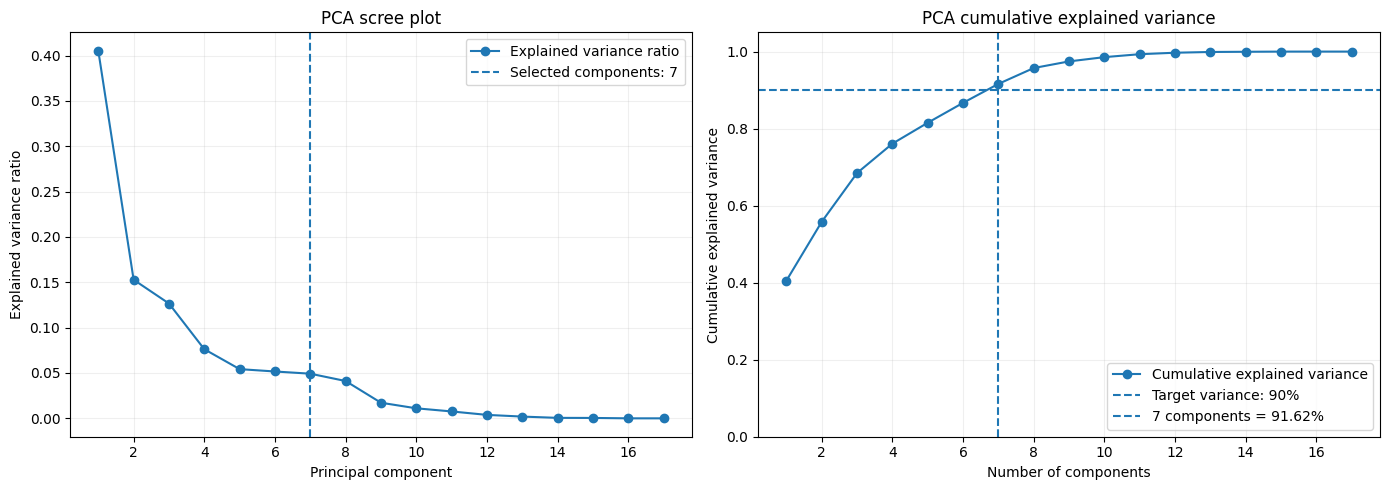

Original X shape: (22542, 17)
PCA-transformed Z shape: (22542, 7)
Selected PCA components: 7
Explained variance ratio: [0.40532836 0.15281487 0.12661964 0.0762264  0.05426474 0.05166111
 0.04923973]
Cumulative explained variance: [0.40532836 0.55814323 0.68476287 0.76098928 0.81525401 0.86691513
 0.91615485]
Total explained variance: 0.9161548523505098
         Z1        Z2        Z3        Z4        Z5        Z6        Z7
0  2.157700  2.169349 -1.353579 -0.030146 -0.424463 -1.389278  1.302468
1  2.193675  2.134881 -1.323168 -0.040818 -0.412388 -1.317244  1.508106
2  2.097022  1.996307 -1.242912 -0.037728 -0.495985 -1.473860  1.012189
3  2.225289  2.077566 -1.232101 -0.069640 -0.492390 -1.230528  1.347286
4  2.220343  2.135307 -1.224658 -0.033600 -0.571688 -0.801395  2.115598


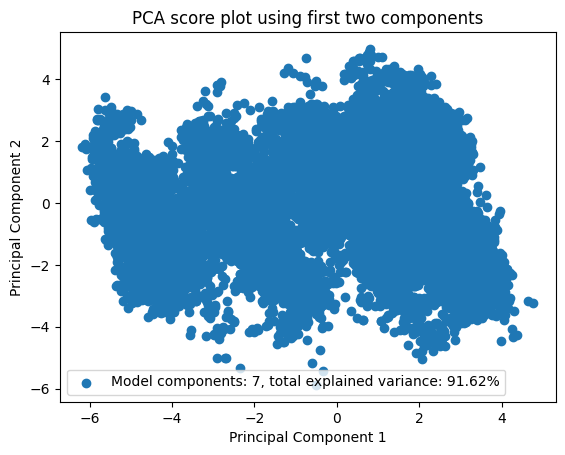

In [11]:
target_variance_pca = 0.90

# Fit a full PCA model first only for component-selection diagnostics.
max_components_pca = min(X.shape[0] - 1, X.shape[1])
pca_full_model = pca_fit(X, n_components=max_components_pca)
pca_variance_df = make_variance_table(pca_full_model["explained_variance_ratio"])

n_components_pca = int(
    pca_variance_df.loc[
        pca_variance_df["Cumulative variance"] >= target_variance_pca,
        "Component",
    ].iloc[0]
)

display(pca_variance_df.head(20))
plot_scree_and_cumulative_variance(
    pca_variance_df,
    selected_components=n_components_pca,
    target_variance=target_variance_pca,
    title_prefix="PCA",
)

# Fit the actual monitoring model with the selected number of components.
pca_model = pca_fit(X, n_components=n_components_pca)
Z_pca = pca_transform(X, pca_model)
evr_pca = pca_model["explained_variance_ratio"]

print("Original X shape:", X.shape)
print("PCA-transformed Z shape:", Z_pca.shape)
print("Selected PCA components:", n_components_pca)
print("Explained variance ratio:", evr_pca.values)
print("Cumulative explained variance:", evr_pca.cumsum().values)
print("Total explained variance:", evr_pca.sum())
print(Z_pca.head())

plt.scatter(Z_pca["Z1"], Z_pca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA score plot using first two components")
plt.legend([f"Model components: {n_components_pca}, total explained variance: {evr_pca.sum()*100:.2f}%"])
plt.show()


The score plot still shows only the first two principal components, but the monitoring model now uses enough components to explain the selected cumulative variance target. This separates visualization from the actual fault detection model.


### Q and T2 statistics for PCA

PCA Q threshold (99.0%): 6.074
PCA T2 threshold (99.0%): 17.039


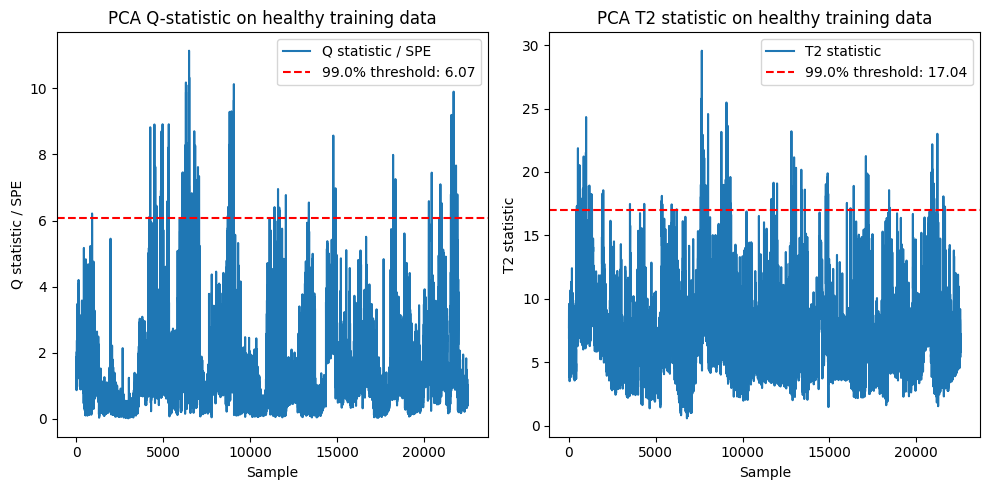

In [12]:
# Q-statistic / SPE
q_train_pca = q_statistic(X, Z_pca, pca_model)

# Hotelling's T2 statistic
t2_train_pca = t2_statistic(Z_pca, pca_model)

# Use a stricter empirical limit for fault detection.
# 95% means about 5% expected alarms on healthy calibration data.
threshold_quantile = 0.99
threshold_q_pca = q_train_pca.quantile(threshold_quantile)
threshold_t2_pca = t2_train_pca.quantile(threshold_quantile)

print(f"PCA Q threshold ({threshold_quantile:.1%}): {threshold_q_pca:.3f}")
print(f"PCA T2 threshold ({threshold_quantile:.1%}): {threshold_t2_pca:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(q_train_pca, label="Q statistic / SPE")
axes[0].axhline(y=threshold_q_pca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_q_pca:.2f}")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("PCA Q-statistic on healthy training data")
axes[0].legend()

axes[1].plot(t2_train_pca, label="T2 statistic")
axes[1].axhline(y=threshold_t2_pca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_t2_pca:.2f}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("PCA T2 statistic on healthy training data")
axes[1].legend()

plt.tight_layout()
plt.show()


A 95% empirical threshold gives roughly 5% expected alarms even on healthy data. For fault detection, 99% or 99.5% is usually a better starting point. The threshold must be estimated from healthy training/calibration data only.


## DPCA transform

,Component,Explained variance ratio,Explained variance (%),Cumulative variance,Cumulative variance (%)
0,1,0.402884,40.288379,0.402884,40.288379
1,2,0.151044,15.104363,0.553927,55.392742
2,3,0.125165,12.516529,0.679093,67.909271
3,4,0.071497,7.149733,0.750590,75.059005
4,5,0.049946,4.994627,0.800536,80.053632
5,6,0.048462,4.846207,0.848998,84.899839
6,7,0.034069,3.406897,0.883067,88.306736
7,8,0.016650,1.664973,0.899717,89.971708
8,9,0.011943,1.194288,0.911660,91.165996
9,10,0.011198,1.119792,0.922858,92.285788


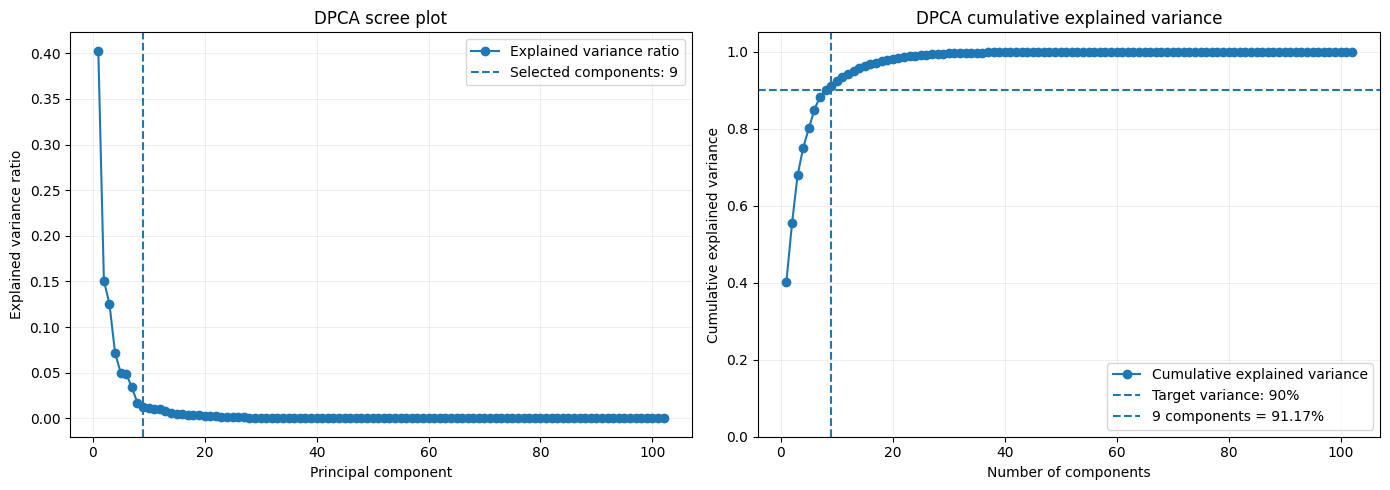

Original X shape: (22542, 17)
DPCA-transformed Z shape: (22537, 9)
Selected DPCA components: 9
Explained variance ratio: [0.40288379 0.15104363 0.12516529 0.07149733 0.04994627 0.04846207
 0.03406897 0.01664973 0.01194288]
Cumulative explained variance: [0.40288379 0.55392742 0.67909271 0.75059005 0.80053632 0.84899839
 0.88306736 0.89971708 0.91165996]
Total explained variance: 0.9116599649526899
         Z1        Z2        Z3        Z4        Z5        Z6        Z7  \
5 -5.206023  4.901889 -3.248663  0.132803 -4.019617 -2.073747 -1.083929   
6 -5.055714  4.808845 -3.120880  0.209129 -4.070455 -1.700622 -1.017039   
7 -4.903096  4.811359 -3.032891  0.311459 -4.106177 -1.232899 -0.967818   
8 -4.732971  4.908354 -3.009298  0.448659 -4.135200 -0.731001 -0.949123   
9 -4.453339  4.970668 -2.985785  0.605548 -4.163254 -0.318261 -0.884969   

         Z8        Z9  
5 -0.180593 -2.076650  
6 -0.110864 -2.145570  
7 -0.057800 -1.916277  
8 -0.029929 -1.516912  
9  0.134615 -0.660376  


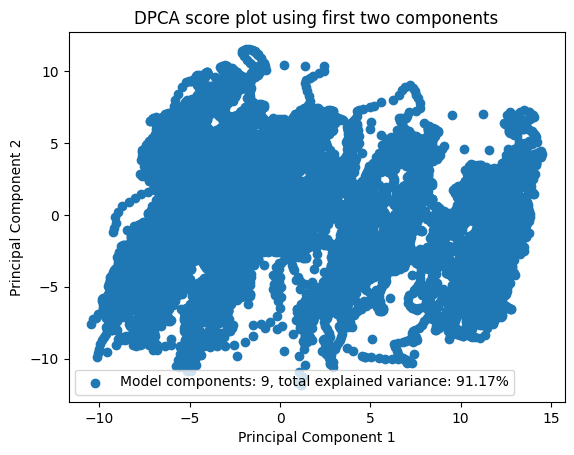

In [13]:
time_lags = 5
target_variance_dpca = 0.90

# Select DPCA components from the standardized lagged healthy training matrix.
X_lagged_for_selection = build_lagged_matrix(X, time_lags)
X_lagged_for_selection = (
    X_lagged_for_selection - X_lagged_for_selection.mean()
) / X_lagged_for_selection.std().replace(0, 1e-12)

# Fit a full PCA model on the lagged matrix for DPCA component-selection diagnostics.
max_components_dpca = min(X_lagged_for_selection.shape[0] - 1, X_lagged_for_selection.shape[1])
dpca_full_model = pca_fit(X_lagged_for_selection, n_components=max_components_dpca)
dpca_variance_df = make_variance_table(dpca_full_model["explained_variance_ratio"])

n_components_dpca = int(
    dpca_variance_df.loc[
        dpca_variance_df["Cumulative variance"] >= target_variance_dpca,
        "Component",
    ].iloc[0]
)

display(dpca_variance_df.head(20))
plot_scree_and_cumulative_variance(
    dpca_variance_df,
    selected_components=n_components_dpca,
    target_variance=target_variance_dpca,
    title_prefix="DPCA",
)

# Fit the actual DPCA monitoring model with the selected number of components.
dpca_model = dpca_fit(X, n_components=n_components_dpca, time_lags=time_lags)
evr_dpca = dpca_model["explained_variance_ratio"]
Z_dpca = dpca_transform(X, dpca_model)

print("Original X shape:", X.shape)
print("DPCA-transformed Z shape:", Z_dpca.shape)
print("Selected DPCA components:", n_components_dpca)
print("Explained variance ratio:", evr_dpca.values)
print("Cumulative explained variance:", evr_dpca.cumsum().values)
print("Total explained variance:", evr_dpca.sum())
print(Z_dpca.head())

plt.scatter(Z_dpca["Z1"], Z_dpca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DPCA score plot using first two components")
plt.legend([f"Model components: {n_components_dpca}, total explained variance: {evr_dpca.sum()*100:.2f}%"])
plt.show()


### Q and T2 statistic for DPCA

DPCA Q threshold (99.0%): 29.373
DPCA T2 threshold (99.0%): 19.574


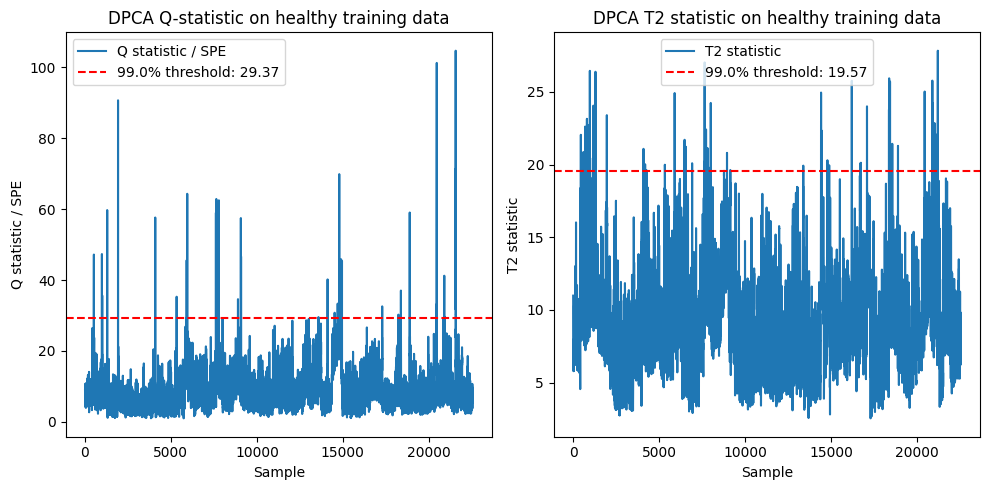

In [14]:
X_lagged = dpca_prepare_matrix(X, dpca_model)

q_values_dpca = q_statistic(X_lagged, Z_dpca, dpca_model["pca_model"])
t2_values_dpca = t2_statistic(Z_dpca, dpca_model["pca_model"])

threshold_q_dpca = q_values_dpca.quantile(threshold_quantile)
threshold_t2_dpca = t2_values_dpca.quantile(threshold_quantile)

print(f"DPCA Q threshold ({threshold_quantile:.1%}): {threshold_q_dpca:.3f}")
print(f"DPCA T2 threshold ({threshold_quantile:.1%}): {threshold_t2_dpca:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(q_values_dpca, label="Q statistic / SPE")
axes[0].axhline(y=threshold_q_dpca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_q_dpca:.2f}")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("DPCA Q-statistic on healthy training data")
axes[0].legend()

axes[1].plot(t2_values_dpca, label="T2 statistic")
axes[1].axhline(y=threshold_t2_dpca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_t2_dpca:.2f}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("DPCA T2 statistic on healthy training data")
axes[1].legend()

plt.tight_layout()
plt.show()


## Preprocessing of FC data

In [15]:

# Process all faulty/test sets with the SAME preprocessor fitted on healthy training data.
# This avoids train/test leakage.

def _transform_and_align(dataset):
    transformed = preprocessor.transform(dataset)
    transformed.sensors = transformed.sensors.reindex(columns=preprocessor.feature_names_out_)
    return transformed

fc_sets_processed = [
    {set_name: _transform_and_align(dataset) for set_name, dataset in case_sets.items()}
    for case_sets in fc_sets_raw
]

# Use this variable in all Shewhart/PCA/DPCA test loops below.
fc_sets = fc_sets_processed

X_test_processed = fc_sets[0]["Set1_1"]
X_test_processed.sensors.head()


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,Level_Top_Sep,Flow_Top_Sep_Out,Density_Top_Riser,Temp_Top_Riser,Level_3Phase_Sep,Pump_Current_PO1,P_mix_zone
0,-1.121776,-1.079499,-1.079417,-0.664637,-0.795776,-0.941516,-0.502750,-1.122479,-0.981933,-0.538784,-0.913100,-0.828215,-1.021548,0.025201,-3.252912,-0.867411,-4.404295
1,-1.164605,-1.119629,-1.127958,-0.768072,-0.657772,-0.978630,-0.283888,-1.123511,-0.981921,-0.538786,-0.933837,-0.846136,-1.021548,0.024254,-3.253307,-1.536984,-4.404295
2,-1.196922,-1.128015,-0.965355,-0.807296,-0.519776,-1.008409,-0.381595,-1.124453,-0.981909,-0.538789,-0.954574,-0.803720,-1.021548,0.023307,-3.253703,-2.262357,-4.404295
3,-1.205176,-1.139044,-0.732364,-0.635165,-0.381797,-1.035743,-0.545742,-1.124766,-0.981896,-0.538792,-0.975313,-0.831997,-1.021284,0.022360,-3.254098,-2.280956,-4.404295
4,-1.220282,-1.168367,-0.746935,-0.392504,-0.282830,-1.063077,-0.377686,-1.124901,-0.981884,-0.538795,-0.858577,-0.788237,-1.020934,0.021413,-3.254493,-0.625621,-4.404295


## FDA Training

In [16]:
# FDA training uses the FIRST set from each faulty case.
# FDA testing will use the remaining sets from each case.

def _set_sort_key(set_name: str):
    # Example: Set3_2 -> (3, 2)
    left, right = set_name.replace("Set", "").split("_")
    return (int(left), int(right))

fda_case_splits = {}
X_train_list = []
y_train_list = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    ordered_set_names = sorted(case_sets.keys(), key=_set_sort_key)
    train_set_name = ordered_set_names[0]
    test_set_names = ordered_set_names[1:]
    fda_case_splits[case_name] = {
        "train_set": train_set_name,
        "test_sets": test_set_names,
    }

    train_dataset = case_sets[train_set_name]
    train_df = train_dataset.sensors.copy()
    train_windows = se_windows[case_name][train_set_name]
    train_fault_mask = is_in_fault_window(np.arange(len(train_df)), train_windows)

    healthy = train_df.loc[~train_fault_mask]
    faulty = train_df.loc[train_fault_mask]

    X_train_list.append(healthy)
    y_train_list.append(np.zeros(len(healthy), dtype=int))
    X_train_list.append(faulty)
    y_train_list.append(np.ones(len(faulty), dtype=int))

X_fda = pd.concat(X_train_list, axis=0, ignore_index=True)
y_fda = np.concatenate(y_train_list)

fda_training_dataset = TimeSeriesDataset(
    name="FDA_training_data_first_set_per_case",
    sensors=X_fda,
    metadata={"description": "FDA train split: first set from each faulty case"},
)

fda_model = FDAModel()
fda_model.fit(fda_training_dataset, y_fda)

fda_train_scores = fda_model.transform(fda_training_dataset)
threshold_quantile_fda = 0.99
threshold_fda = chi2.ppf(threshold_quantile_fda, df=fda_model.n_components_)

fda_split_rows = []
for case_name, split in fda_case_splits.items():
    for test_set in split["test_sets"]:
        fda_split_rows.append({
            "Case": case_name,
            "FDA train set": split["train_set"],
            "FDA test set": test_set,
        })
fda_split_df = pd.DataFrame(fda_split_rows)

print("FDA projection components:", fda_model.n_components_)
print(f"FDA chi-square threshold ({threshold_quantile_fda:.1%}): {threshold_fda:.3f}")
print("FDA class labels:", fda_model.class_labels_)
print("FDA train/test split per case:")
display(fda_split_df)
print("FDA projected training scores head:")
display(fda_train_scores.head())

FDA projection components: 1
FDA chi-square threshold (99.0%): 6.635
FDA class labels: [np.int64(0), np.int64(1)]
FDA train/test split per case:


,Case,FDA train set,FDA test set
0,FaultyCase1,Set1_1,Set1_2
1,FaultyCase1,Set1_1,Set1_3
2,FaultyCase2,Set2_1,Set2_2
3,FaultyCase2,Set2_1,Set2_3
4,FaultyCase3,Set3_1,Set3_2
5,FaultyCase3,Set3_1,Set3_3
6,FaultyCase4,Set4_1,Set4_2
7,FaultyCase4,Set4_1,Set4_3
8,FaultyCase5,Set5_1,Set5_2
9,FaultyCase6,Set6_1,Set6_2


FDA projected training scores head:


,FDA1
0,-0.114536
1,-0.105996
2,-0.102379
3,-0.108077
4,-0.139201


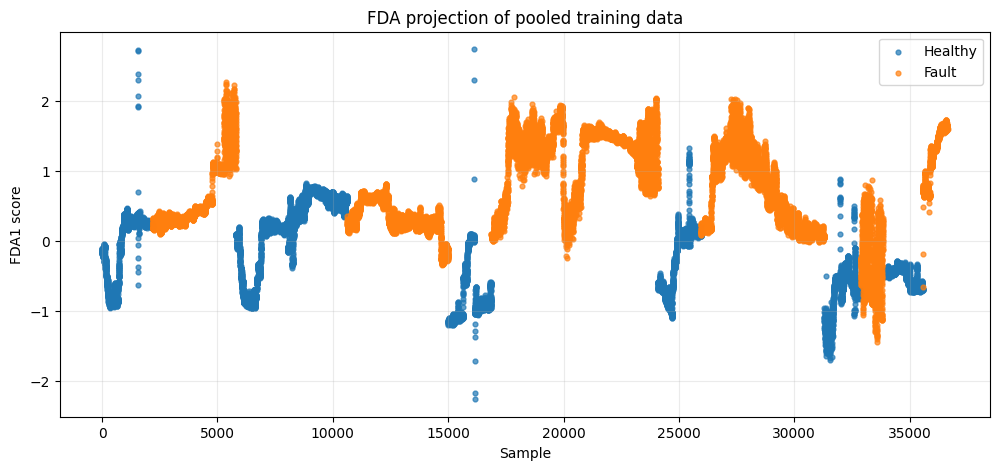

In [17]:

# Visualize the pooled FDA projection in the style of the MATLAB example.
plot_df = pd.DataFrame({
    "Sample": np.arange(len(y_fda)),
    "FDA1": fda_train_scores.iloc[:, 0].to_numpy(),
    "Class": np.where(y_fda == 0, "Healthy", "Fault"),
})

plt.figure(figsize=(12, 5))
for label, color in [("Healthy", "tab:blue"), ("Fault", "tab:orange")]:
    subset = plot_df[plot_df["Class"] == label]
    plt.scatter(subset["Sample"], subset["FDA1"], s=12, alpha=0.7, label=label, color=color)

plt.xlabel("Sample")
plt.ylabel("FDA1 score")
plt.title("FDA projection of pooled training data")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()



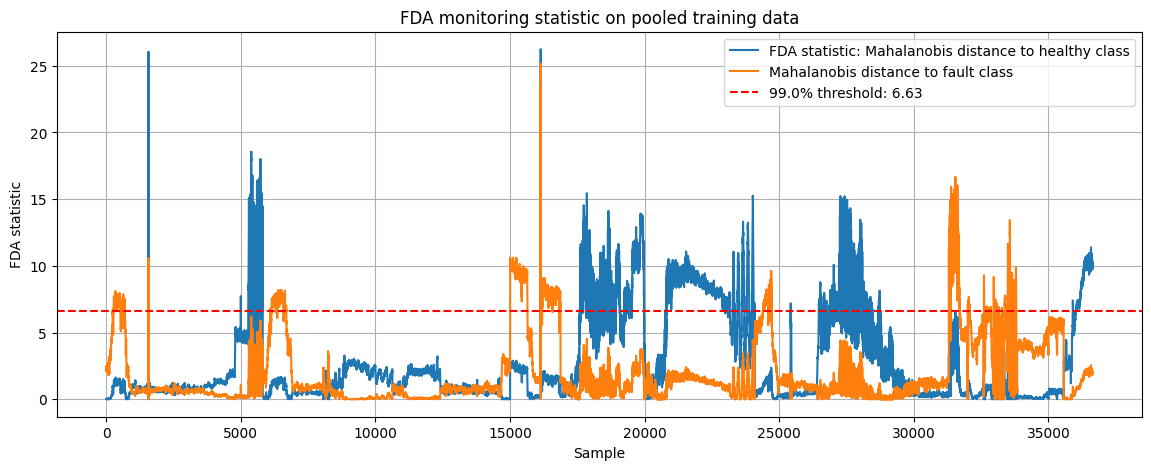

In [18]:
_, _, d_healthy_train, d_fault_train, _ = fda_model.predict(fda_training_dataset)

fda_stat = d_healthy_train

plt.figure(figsize=(14, 5))
plt.plot(fda_stat, label="FDA statistic: Mahalanobis distance to healthy class")
plt.plot(d_fault_train, label="Mahalanobis distance to fault class")
plt.axhline(y=threshold_fda, color="r", linestyle="--", label=f"{threshold_quantile_fda:.1%} threshold: {threshold_fda:.2f}")

plt.title("FDA monitoring statistic on pooled training data")
plt.xlabel("Sample")
plt.ylabel("FDA statistic")
plt.legend()
plt.grid(True)
plt.show()



# Testing - Faulty cases

## Shewhart testing

In [19]:
# Build a Shewhart summary for every case, set, sensor and per-fault-window; export it.

def _fault_windows_from_list(window_values):
    return list(zip(window_values[::2], window_values[1::2]))

def _fault_mask(length, fault_windows):
    mask = np.zeros(length, dtype=bool)
    for start, end in fault_windows:
        mask[start : end + 1] = True
    return mask

shew_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name in case_sets.keys():
        X_fault = case_sets[set_name].sensors
        fault_windows = _fault_windows_from_list(se_windows[case_name][set_name])
        fault_mask = _fault_mask(len(X_fault), fault_windows)
        non_fault_samples = int((~fault_mask).sum())

        for sensor in X_fault.columns:
            sensor_values = X_fault[sensor]
            u_threshold = shewhart_thresholds[sensor][0]
            l_threshold = shewhart_thresholds[sensor][1]
            alarm_mask = (sensor_values > u_threshold) | (sensor_values < l_threshold)
            alarm_indices = np.flatnonzero(alarm_mask.to_numpy())

            # False alarms: counts before first window and after last window
            pre_false = int(((np.arange(len(sensor_values)) < fault_windows[0][0]) & alarm_mask).sum()) if len(fault_windows) > 0 else int((alarm_mask & ~fault_mask).sum())
            post_false = int(((np.arange(len(sensor_values)) > fault_windows[-1][1]) & alarm_mask).sum()) if len(fault_windows) > 0 else 0
            total_false = int((alarm_mask & ~fault_mask).sum())
            false_alarm_rate = float(total_false / non_fault_samples) if non_fault_samples > 0 else np.nan

            anomalies = int(alarm_mask.sum())

            shew_alarm_mask = alarm_mask.to_numpy()
            sample_index = X_fault.index.to_numpy()
            shew_metrics = compute_detection_metrics(
                shew_alarm_mask,
                se_windows[case_name][set_name],
                sample_index,
            )

            # Per-window delays and detection counting (one row per fault window)
            for fi, (fw_start, fw_end) in enumerate(fault_windows, start=1):
                in_window = alarm_indices[(alarm_indices >= fw_start) & (alarm_indices <= fw_end)]
                if len(in_window) > 0:
                    delay = int(in_window[0] - fw_start)
                    detected = True
                else:
                    delay = np.nan
                    detected = False

                shew_results.append({
                    "Case": case_name,
                    "Set": set_name,
                    "FaultIndex": fi,
                    "Method": "Shewhart",
                    "Detected": detected,
                    "Samples": len(sensor_values),
                    "Sensor": sensor,
                    "Detection rate": shew_metrics["Detection rate"],
                    "False alarm rate": false_alarm_rate,
                    "Detection delay": delay,
                    "Alarm samples": anomalies,
                    "Fault samples": shew_metrics["Fault samples"],
                    "Normal samples": shew_metrics["Normal samples"],
                    "Alarm samples in fault window": shew_metrics["Alarm samples in fault window"],
                    "FaultStart": fw_start,
                    "FaultEnd": fw_end,
                    "False alarms pre": pre_false,
                    "False alarms post": post_false,
                    "False alarm samples": shew_metrics["False alarm samples"],
                })

shew_results_df = pd.DataFrame(shew_results)
# order columns for readability
# cols = [c for c in ["Case","Set","FaultIndex","FaultStart","FaultEnd","Sensor","Samples","Detected","Detection Delay","Sensor Anomalies","False alarms pre","False alarms post","False alarm rate"] if c in shew_results_df.columns]
# shew_results_df = shew_results_df[cols]

# shew_results_df.to_csv("shewhart_results.csv", index=False)
print("Shewhart Results:")
shew_results_df

Shewhart Results:


,Case,Set,FaultIndex,Method,Detected,Samples,Sensor,Detection rate,False alarm rate,Detection delay,Alarm samples,Fault samples,Normal samples,Alarm samples in fault window,FaultStart,FaultEnd,False alarms pre,False alarms post,False alarm samples
0,FaultyCase1,Set1_1,1,Shewhart,True,5811,Air_Delivery_P,0.494192,0.005923,1829.0,1800,3616,2195,1787,1566,5181,0,13,13
1,FaultyCase1,Set1_1,1,Shewhart,True,5811,P_Bottom_Riser,0.071073,0.004556,3100.0,267,3616,2195,257,1566,5181,0,10,10
2,FaultyCase1,Set1_1,1,Shewhart,True,5811,P_Top_Riser,0.081029,0.101595,2334.0,516,3616,2195,293,1566,5181,137,86,223
3,FaultyCase1,Set1_1,1,Shewhart,True,5811,P_Top_Separator,0.069137,0.101139,3083.0,472,3616,2195,250,1566,5181,128,94,222
4,FaultyCase1,Set1_1,1,Shewhart,True,5811,P_3Phase_Separator,0.123341,0.187244,480.0,857,3616,2195,446,1566,5181,261,150,411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,FaultyCase6,Set6_2,1,Shewhart,True,4830,Density_Top_Riser,0.030319,0.000000,483.0,115,3793,1037,115,1037,4830,0,0,0
319,FaultyCase6,Set6_2,1,Shewhart,False,4830,Temp_Top_Riser,0.000000,0.000000,NaN,0,3793,1037,0,1037,4830,0,0,0
320,FaultyCase6,Set6_2,1,Shewhart,False,4830,Level_3Phase_Sep,0.000000,0.000000,NaN,0,3793,1037,0,1037,4830,0,0,0
321,FaultyCase6,Set6_2,1,Shewhart,True,4830,Pump_Current_PO1,0.000527,0.000000,2128.0,2,3793,1037,2,1037,4830,0,0,0


Description for each column in the results:
- *Case*: The name of the faulty case (e.g., FaultyCase1).
- *Set*: The specific set within the case (e.g., Set1_1).
- *FaultIndex*: The index of the fault window (for FC5 with multiple faults).
- *FaultStart*: The starting sample index of the fault window.
- *FaultEnd*: The ending sample index of the fault window.
- *Sensor*: The name of the sensor for which the Shewhart chart was evaluated.
- *Samples*: The total number of samples in that case/set/sensor.
- *Detected*: Whether the Shewhart chart detected an anomaly within the fault window (True/False).
- *Delay*: Samples between the fault start and the first detected violation (NaN if not detected).
- *Anomalies*: Total number of violations of Shewhart limits for that sensor.
- *False alarms pre*: The number of violations before fault start.
- *False alarms post*: The number of violations after fault end.
- *False alarm rate*: (total false alarms) / (number of non-fault samples).

## PCA testing

PCA on Set1_1: Q-statistic detection delay: 0 samples
PCA on Set1_1: T2 statistic detection delay: 0 samples
PCA on Set1_1: Number of Q-statistic alarm samples: 5603 of 5811 samples
PCA on Set1_1: Number of T2 statistic alarm samples: 5785 of 5811 samples


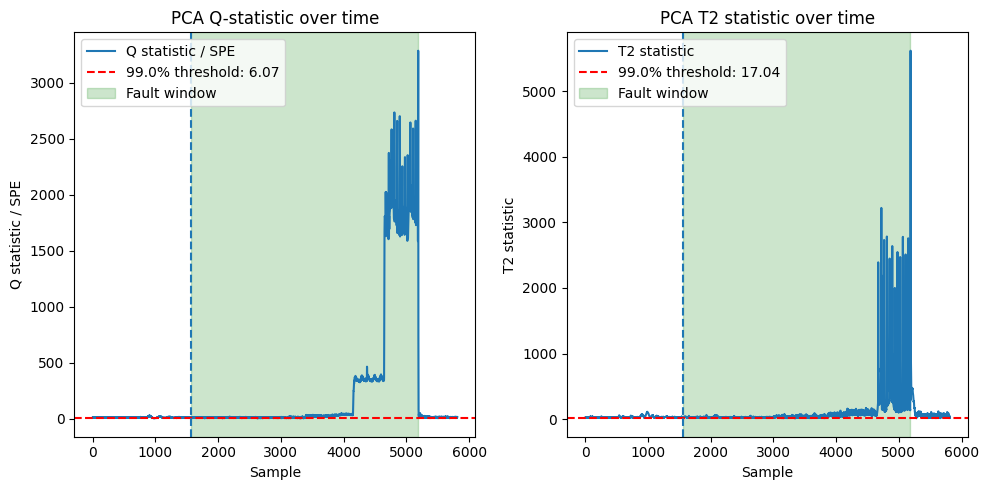

In [20]:
# A single PCA test on FaultyCase1 Set1_1
case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

PCA_X_FC1_1 = fc_sets[0][set_name].sensors
PCA_Z_FC1_1 = pca_transform(PCA_X_FC1_1, pca_model)
PCA_q_FC1_1 = q_statistic(PCA_X_FC1_1, PCA_Z_FC1_1, pca_model)
PCA_t2_FC1_1 = t2_statistic(PCA_Z_FC1_1, pca_model)

q_alarm_mask = (PCA_q_FC1_1 > threshold_q_pca).to_numpy()
t2_alarm_mask = (PCA_t2_FC1_1 > threshold_t2_pca).to_numpy()

print(f"PCA on {set_name}: Q-statistic detection delay: {first_detection_delay(q_alarm_mask, windows, PCA_q_FC1_1.index)} samples")
print(f"PCA on {set_name}: T2 statistic detection delay: {first_detection_delay(t2_alarm_mask, windows, PCA_t2_FC1_1.index)} samples")
print(f"PCA on {set_name}: Number of Q-statistic alarm samples: {int(q_alarm_mask.sum())} of {len(PCA_q_FC1_1)} samples")
print(f"PCA on {set_name}: Number of T2 statistic alarm samples: {int(t2_alarm_mask.sum())} of {len(PCA_t2_FC1_1)} samples")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(PCA_q_FC1_1, label='Q statistic / SPE')
axes[0].axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_q_pca:.2f}')
add_fault_spans(axes[0], windows, color='g', label='Fault window')
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("PCA Q-statistic over time")
axes[0].legend()

axes[1].plot(PCA_t2_FC1_1, label='T2 statistic')
axes[1].axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_t2_pca:.2f}')
add_fault_spans(axes[1], windows, color='g', label='Fault window')
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("PCA T2 statistic over time")
axes[1].legend()
plt.tight_layout()
plt.show()


In [21]:
# PCA evaluation on all faulty/test sets.
# Uses all fault windows and preserves sample index.

pca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        Z_fault = pca_transform(X_fault, pca_model)
        q_fault = q_statistic(X_fault, Z_fault, pca_model)
        t2_fault = t2_statistic(Z_fault, pca_model)

        q_alarm_mask = (q_fault > threshold_q_pca).to_numpy()
        t2_alarm_mask = (t2_fault > threshold_t2_pca).to_numpy()

        q_metrics = compute_detection_metrics(
            q_alarm_mask,
            windows,
            q_fault.index,
        )

        t2_metrics = compute_detection_metrics(
            t2_alarm_mask,
            windows,
            t2_fault.index,
        )

        pca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),

            "Q detection rate": q_metrics["Detection rate"],
            "Q false alarm rate": q_metrics["False alarm rate"],
            "Q detection delay": q_metrics["Detection delay"],
            "Q alarm samples": int(np.sum(q_alarm_mask)),
            "Q alarm samples in fault window": q_metrics["Alarm samples in fault window"],
            "Q false alarm samples": q_metrics["False alarm samples"],

            "T2 detection rate": t2_metrics["Detection rate"],
            "T2 false alarm rate": t2_metrics["False alarm rate"],
            "T2 detection delay": t2_metrics["Detection delay"],
            "T2 alarm samples": int(np.sum(t2_alarm_mask)),
            "T2 alarm samples in fault window": t2_metrics["Alarm samples in fault window"],
            "T2 false alarm samples": t2_metrics["False alarm samples"],

            "Fault samples": q_metrics["Fault samples"],
            "Normal samples": q_metrics["Normal samples"],
        })

pca_results_df = pd.DataFrame(pca_results)
print("PCA Results:")
pca_results_df

PCA Results:


,Case,Set,Samples,Q detection rate,Q false alarm rate,Q detection delay,Q alarm samples,Q alarm samples in fault window,Q false alarm samples,T2 detection rate,T2 false alarm rate,T2 detection delay,T2 alarm samples,T2 alarm samples in fault window,T2 false alarm samples,Fault samples,Normal samples
0,FaultyCase1,Set1_1,5811,0.965155,0.962642,0,5603,3490,2113,0.994192,0.997722,0,5785,3595,2190,3616,2195
1,FaultyCase1,Set1_2,4467,0.818007,0.847697,1,3694,2553,1141,0.971163,0.966568,0,4332,3031,1301,3121,1346
2,FaultyCase1,Set1_3,4321,1.000000,1.000000,0,4321,3001,1320,0.281573,0.371970,113,1336,845,491,3001,1320
3,FaultyCase2,Set2_1,9192,0.872399,0.915958,0,8229,3815,4414,0.975989,0.920730,0,8705,4268,4437,4373,4819
4,FaultyCase2,Set2_2,3496,0.998166,0.958935,0,3438,2177,1261,0.367721,0.734601,0,1768,802,966,2181,1315
5,FaultyCase2,Set2_3,3421,0.751989,0.815421,0,2654,1607,1047,0.893308,0.985202,0,3174,1909,1265,2137,1284
6,FaultyCase3,Set3_1,9090,1.000000,0.845702,0,8801,7217,1584,1.000000,0.973305,0,9040,7217,1823,7217,1873
7,FaultyCase3,Set3_2,6272,1.000000,0.986357,0,6262,5539,723,1.000000,0.983629,0,6260,5539,721,5539,733
8,FaultyCase3,Set3_3,10764,0.999889,0.903514,0,10590,8970,1620,0.991082,0.905745,0,10515,8891,1624,8971,1793
9,FaultyCase4,Set4_1,7208,0.997566,0.972133,0,7143,5329,1814,0.999064,0.997856,0,7199,5337,1862,5342,1866


In [22]:
# # This plots Q and T2 statistics for all sets in all cases

# for case_name, case_sets in zip(se_windows.keys(), fc_sets):
#     for set_name, fault_window in zip(case_sets.keys(), se_windows[case_name]):
#         X_fault = case_sets[set_name].sensors
#         Z_fault = pca_transform(X_fault, pca_model)
#         q_fault = q_statistic(X_fault, Z_fault)
#         t2_fault = t2_statistic(Z_fault)

#         n_q_anomalies = np.sum(q_fault > threshold_q_pca)
#         n_t2_anomalies = np.sum(t2_fault > threshold_t2_pca)

#         print(f"PCA on {case_name} {set_name}: Number of Q-statistic anomalies: {n_q_anomalies} of {len(X_fault)} samples")
#         print(f"PCA on {case_name} {set_name}: Number of T2 statistic anomalies: {n_t2_anomalies} of {len(X_fault)} samples")

#         plt.figure(figsize=(10, 5))
#         plt.subplot(1, 2, 1)
#         plt.plot(q_fault, label='Q statistic / SPE')
#         plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("Q statistic / SPE")
#         plt.title(f"PCA Q-statistic over time - {case_name} {set_name}")
#         plt.legend()

#         plt.subplot(1, 2, 2)
#         plt.plot(t2_fault, label='T2 statistic')
#         plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("T2 statistic")
#         plt.title(f"PCA T2 statistic over time - {case_name} {set_name}")
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

## DPCA testing

DPCA on Set1_1: Q-statistic detection delay: 0 samples
DPCA on Set1_1: T2 statistic detection delay: 0 samples
DPCA on Set1_1: Number of Q-statistic alarm samples: 4744 of 5806 samples
DPCA on Set1_1: Number of T2 statistic alarm samples: 5806 of 5806 samples


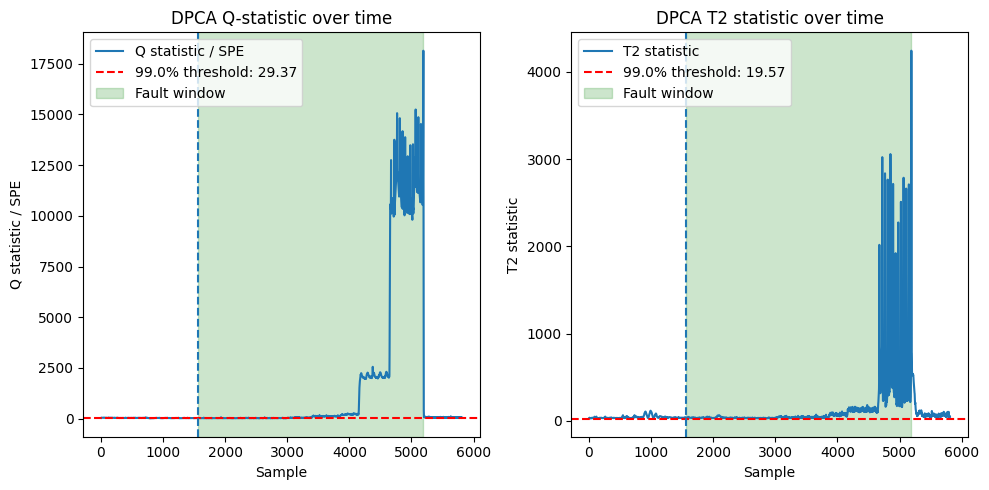

In [23]:
# A single DPCA test on FaultyCase1 Set1_1
case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

DPCA_X_FC1_1 = fc_sets[0][set_name].sensors
DPCA_X_FC1_1_lagged = dpca_prepare_matrix(DPCA_X_FC1_1, dpca_model)
DPCA_Z_FC1_1 = dpca_transform(DPCA_X_FC1_1, dpca_model)
DPCA_q_FC1_1 = q_statistic(DPCA_X_FC1_1_lagged, DPCA_Z_FC1_1, dpca_model["pca_model"])
DPCA_t2_FC1_1 = t2_statistic(DPCA_Z_FC1_1, dpca_model["pca_model"])

q_alarm_mask = (DPCA_q_FC1_1 > threshold_q_dpca).to_numpy()
t2_alarm_mask = (DPCA_t2_FC1_1 > threshold_t2_dpca).to_numpy()

print(f"DPCA on {set_name}: Q-statistic detection delay: {first_detection_delay(q_alarm_mask, windows, DPCA_q_FC1_1.index)} samples")
print(f"DPCA on {set_name}: T2 statistic detection delay: {first_detection_delay(t2_alarm_mask, windows, DPCA_t2_FC1_1.index)} samples")
print(f"DPCA on {set_name}: Number of Q-statistic alarm samples: {int(q_alarm_mask.sum())} of {len(DPCA_q_FC1_1)} samples")
print(f"DPCA on {set_name}: Number of T2 statistic alarm samples: {int(t2_alarm_mask.sum())} of {len(DPCA_t2_FC1_1)} samples")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(DPCA_q_FC1_1, label='Q statistic / SPE')
axes[0].axhline(y=threshold_q_dpca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_q_dpca:.2f}')
add_fault_spans(axes[0], windows, color='g', label='Fault window')
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("DPCA Q-statistic over time")
axes[0].legend()

axes[1].plot(DPCA_t2_FC1_1, label='T2 statistic')
axes[1].axhline(y=threshold_t2_dpca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_t2_dpca:.2f}')
add_fault_spans(axes[1], windows, color='g', label='Fault window')
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("DPCA T2 statistic over time")
axes[1].legend()
plt.tight_layout()
plt.show()


In [24]:
# DPCA evaluation on all faulty/test sets.
# DPCA statistics start at original sample index = time_lags, so use the Series index for delays and false alarms.

dpca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        X_fault_lagged = dpca_prepare_matrix(X_fault, dpca_model)
        Z_fault = dpca_transform(X_fault, dpca_model)
        q_fault = q_statistic(X_fault_lagged, Z_fault, dpca_model["pca_model"])
        t2_fault = t2_statistic(Z_fault, dpca_model["pca_model"])

        q_alarm_mask = (q_fault > threshold_q_dpca).to_numpy()
        t2_alarm_mask = (t2_fault > threshold_t2_dpca).to_numpy()

        q_metrics = compute_detection_metrics(
            q_alarm_mask,
            windows,
            q_fault.index,
        )

        t2_metrics = compute_detection_metrics(
            t2_alarm_mask,
            windows,
            t2_fault.index,
        )

        dpca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),

            "Q detection rate": q_metrics["Detection rate"],
            "Q false alarm rate": q_metrics["False alarm rate"],
            "Q detection delay": q_metrics["Detection delay"],
            "Q alarm samples": int(np.sum(q_alarm_mask)),
            "Q alarm samples in fault window": q_metrics["Alarm samples in fault window"],
            "Q false alarm samples": q_metrics["False alarm samples"],

            "T2 detection rate": t2_metrics["Detection rate"],
            "T2 false alarm rate": t2_metrics["False alarm rate"],
            "T2 detection delay": t2_metrics["Detection delay"],
            "T2 alarm samples": int(np.sum(t2_alarm_mask)),
            "T2 alarm samples in fault window": t2_metrics["Alarm samples in fault window"],
            "T2 false alarm samples": t2_metrics["False alarm samples"],

            "Fault samples": q_metrics["Fault samples"],
            "Normal samples": q_metrics["Normal samples"],
        })

dpca_results_df = pd.DataFrame(dpca_results)
print("DPCA Results:")
dpca_results_df

DPCA Results:


,Case,Set,Samples,Q detection rate,Q false alarm rate,Q detection delay,Q alarm samples,Q alarm samples in fault window,Q false alarm samples,T2 detection rate,T2 false alarm rate,T2 detection delay,T2 alarm samples,T2 alarm samples in fault window,T2 false alarm samples,Fault samples,Normal samples
0,FaultyCase1,Set1_1,5811,0.789823,0.862100,0,4744,2856,1888,1.000000,1.000000,0,5806,3616,2190,3616,2190
1,FaultyCase1,Set1_2,4467,0.999359,0.983594,0,4438,3119,1319,1.000000,1.000000,0,4462,3121,1341,3121,1341
2,FaultyCase1,Set1_3,4321,1.000000,1.000000,0,4316,3001,1315,1.000000,1.000000,0,4316,3001,1315,3001,1315
3,FaultyCase2,Set2_1,9192,0.932312,0.959493,0,8696,4077,4619,1.000000,1.000000,0,9187,4373,4814,4373,4814
4,FaultyCase2,Set2_2,3496,0.888583,0.593130,0,2715,1938,777,1.000000,1.000000,0,3491,2181,1310,2181,1310
5,FaultyCase2,Set2_3,3421,0.878334,0.982017,0,3133,1877,1256,1.000000,1.000000,0,3416,2137,1279,2137,1279
6,FaultyCase3,Set3_1,9090,1.000000,0.877944,0,8857,7217,1640,1.000000,1.000000,0,9085,7217,1868,7217,1868
7,FaultyCase3,Set3_2,6272,1.000000,0.943681,0,6226,5539,687,1.000000,1.000000,0,6267,5539,728,5539,728
8,FaultyCase3,Set3_3,10764,0.998885,0.244966,10,9399,8961,438,1.000000,1.000000,0,10759,8971,1788,8971,1788
9,FaultyCase4,Set4_1,7208,0.978472,0.797958,0,6712,5227,1485,1.000000,1.000000,0,7203,5342,1861,5342,1861


## FDA Testing

In [25]:
# FDA evaluation uses the remaining sets from each case (after training on each case's first set).

fda_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    split = fda_case_splits[case_name]
    for set_name in split["test_sets"]:
        dataset = case_sets[set_name]
        windows = se_windows[case_name][set_name]

        pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)
        fda_alarm_mask = d_healthy > threshold_fda
        sample_index = np.arange(len(fda_alarm_mask))

        # Monitoring-style FDA metrics (comparable with PCA/DPCA summaries).
        fda_metrics = compute_detection_metrics(
            fda_alarm_mask,
            windows,
            sample_index,
        )

        # Classification-style FDA metrics (more natural for supervised FDA).
        y_true = is_in_fault_window(sample_index, windows).astype(int)
        y_pred = fda_alarm_mask.astype(int)

        tp = int(np.sum((y_pred == 1) & (y_true == 1)))
        tn = int(np.sum((y_pred == 0) & (y_true == 0)))
        fp = int(np.sum((y_pred == 1) & (y_true == 0)))
        fn = int(np.sum((y_pred == 0) & (y_true == 1)))

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else np.nan
        accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else np.nan
        balanced_accuracy = ((recall + specificity) / 2) if (not np.isnan(recall) and not np.isnan(specificity)) else np.nan

        fda_results.append({
            "Case": case_name,
            "Set": set_name,
            "Method": "FDA",
            "FDA train set": split["train_set"],
            "Samples": len(d_healthy),
            "Detection rate": fda_metrics["Detection rate"],
            "False alarm rate": fda_metrics["False alarm rate"],
            "Detection delay": fda_metrics["Detection delay"],
            "Alarm samples": int(np.sum(fda_alarm_mask)),
            "Alarm samples in fault window": fda_metrics["Alarm samples in fault window"],
            "False alarm samples": fda_metrics["False alarm samples"],
            "Fault samples": fda_metrics["Fault samples"],
            "Normal samples": fda_metrics["Normal samples"],
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Precision": precision,
            "Recall": recall,
            "Specificity": specificity,
            "F1": f1,
            "Accuracy": accuracy,
            "Balanced accuracy": balanced_accuracy,
        })

fda_results_df = pd.DataFrame(fda_results)
print("FDA Results:")
fda_results_df

FDA Results:


,Case,Set,Method,FDA train set,Samples,Detection rate,False alarm rate,Detection delay,Alarm samples,Alarm samples in fault window,...,TP,TN,FP,FN,Precision,Recall,Specificity,F1,Accuracy,Balanced accuracy
0,FaultyCase1,Set1_2,FDA,Set1_1,4467,0.000641,0.006686,2775.0,11,2,...,2,1337,9,3119,0.181818,0.000641,0.993314,0.001277,0.299754,0.496977
1,FaultyCase1,Set1_3,FDA,Set1_1,4321,0.029324,0.004545,2428.0,94,88,...,88,1314,6,2913,0.936170,0.029324,0.995455,0.056866,0.324462,0.512389
2,FaultyCase2,Set2_2,FDA,Set2_1,3496,0.000000,0.000000,NaN,0,0,...,0,1315,0,2181,NaN,0.000000,1.000000,NaN,0.376144,0.500000
3,FaultyCase2,Set2_3,FDA,Set2_1,3421,0.000000,0.000000,NaN,0,0,...,0,1284,0,2137,NaN,0.000000,1.000000,NaN,0.375329,0.500000
4,FaultyCase3,Set3_2,FDA,Set3_1,6272,0.150027,0.005457,4664.0,835,831,...,831,729,4,4708,0.995210,0.150027,0.994543,0.260747,0.248724,0.572285
5,FaultyCase3,Set3_3,FDA,Set3_1,10764,0.586222,0.018405,2510.0,5292,5259,...,5259,1760,33,3712,0.993764,0.586222,0.981595,0.737433,0.652081,0.783909
6,FaultyCase4,Set4_2,FDA,Set4_1,4451,0.000000,0.035862,3036.0,52,0,...,0,1398,52,3001,0.000000,0.000000,0.964138,NaN,0.314087,0.482069
7,FaultyCase4,Set4_3,FDA,Set4_1,3661,0.000666,0.000000,600.0,2,2,...,2,660,0,2999,1.000000,0.000666,1.000000,0.001332,0.180825,0.500333
8,FaultyCase5,Set5_2,FDA,Set5_1,10608,0.163975,0.053132,40.0,1051,721,...,721,5881,330,3676,0.686013,0.163975,0.946868,0.264684,0.622360,0.555422
9,FaultyCase6,Set6_2,FDA,Set6_1,4830,0.998945,0.000000,4.0,3789,3789,...,3789,1037,0,4,1.000000,0.998945,1.000000,0.999472,0.999172,0.999473


## Summary

In [26]:
# =========================================================
# SUMMARY TABLES PER MODEL
# =========================================================

def format_percentage_columns(df, columns):
    df = df.copy()

    for col in columns:
        df[col] = ((df[col] * 100).round(2)).astype(str) + " %"

    return df


# =========================================================
# SHEWHART SUMMARY
# =========================================================

shewhart_summary_df = shew_results_df[
    [
        "Case",
        "Set",
        "Sensor",
        "FaultIndex",
        "Detection rate",
        "False alarm rate",
        "Detection delay",
        "Alarm samples",
        "False alarm samples",
    ]
] .copy()

shewhart_summary_df = format_percentage_columns(
    shewhart_summary_df,
    [
        "Detection rate",
        "False alarm rate",
    ]
)

print("=================================================")
print("SHEWHART SUMMARY")
print("=================================================")

display(shewhart_summary_df)


# =========================================================
# PCA SUMMARY
# =========================================================

pca_summary_df = pd.DataFrame({
    "Case": pca_results_df["Case"],
    "Set": pca_results_df["Set"],

    "Q detection rate": pca_results_df["Q detection rate"],
    "Q false alarm rate": pca_results_df["Q false alarm rate"],
    "Q detection delay": pca_results_df["Q detection delay"],

    "T2 detection rate": pca_results_df["T2 detection rate"],
    "T2 false alarm rate": pca_results_df["T2 false alarm rate"],
    "T2 detection delay": pca_results_df["T2 detection delay"],
})

pca_summary_df = format_percentage_columns(
    pca_summary_df,
    [
        "Q detection rate",
        "Q false alarm rate",
        "T2 detection rate",
        "T2 false alarm rate",
    ]
)

print("=================================================")
print("PCA SUMMARY")
print("=================================================")

display(pca_summary_df)


# =========================================================
# DPCA SUMMARY
# =========================================================

dpca_summary_df = pd.DataFrame({
    "Case": dpca_results_df["Case"],
    "Set": dpca_results_df["Set"],

    "Q detection rate": dpca_results_df["Q detection rate"],
    "Q false alarm rate": dpca_results_df["Q false alarm rate"],
    "Q detection delay": dpca_results_df["Q detection delay"],

    "T2 detection rate": dpca_results_df["T2 detection rate"],
    "T2 false alarm rate": dpca_results_df["T2 false alarm rate"],
    "T2 detection delay": dpca_results_df["T2 detection delay"],
})

dpca_summary_df = format_percentage_columns(
    dpca_summary_df,
    [
        "Q detection rate",
        "Q false alarm rate",
        "T2 detection rate",
        "T2 false alarm rate",
    ]
)

print("=================================================")
print("DPCA SUMMARY")
print("=================================================")

display(dpca_summary_df)


# =========================================================
# FDA SUMMARY
# =========================================================

fda_summary_df = fda_results_df[
    [
        "Case",
        "FDA train set",
        "Set",
        "Detection rate",
        "False alarm rate",
        "Detection delay",
        "Alarm samples",
        "False alarm samples",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "Accuracy",
        "Balanced accuracy",
    ]
] .copy()

fda_summary_df = format_percentage_columns(
    fda_summary_df,
    [
        "Detection rate",
        "False alarm rate",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "Accuracy",
        "Balanced accuracy",
    ]
)

print("=================================================")
print("FDA SUMMARY")
print("=================================================")

display(fda_summary_df)

fda_case_summary_df = fda_results_df.groupby("Case", as_index=False).agg({
    "Detection rate": "mean",
    "False alarm rate": "mean",
    "Precision": "mean",
    "Recall": "mean",
    "Specificity": "mean",
    "F1": "mean",
    "Accuracy": "mean",
    "Balanced accuracy": "mean",
})

fda_case_summary_df = format_percentage_columns(
    fda_case_summary_df,
    [
        "Detection rate",
        "False alarm rate",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "Accuracy",
        "Balanced accuracy",
    ]
)

print("FDA CASE-LEVEL AVERAGE METRICS")
display(fda_case_summary_df)

SHEWHART SUMMARY


,Case,Set,Sensor,FaultIndex,Detection rate,False alarm rate,Detection delay,Alarm samples,False alarm samples
0,FaultyCase1,Set1_1,Air_Delivery_P,1,49.42 %,0.59 %,1829.0,1800,13
1,FaultyCase1,Set1_1,P_Bottom_Riser,1,7.11 %,0.46 %,3100.0,267,10
2,FaultyCase1,Set1_1,P_Top_Riser,1,8.1 %,10.16 %,2334.0,516,223
3,FaultyCase1,Set1_1,P_Top_Separator,1,6.91 %,10.11 %,3083.0,472,222
4,FaultyCase1,Set1_1,P_3Phase_Separator,1,12.33 %,18.72 %,480.0,857,411
...,...,...,...,...,...,...,...,...,...
318,FaultyCase6,Set6_2,Density_Top_Riser,1,3.03 %,0.0 %,483.0,115,0
319,FaultyCase6,Set6_2,Temp_Top_Riser,1,0.0 %,0.0 %,NaN,0,0
320,FaultyCase6,Set6_2,Level_3Phase_Sep,1,0.0 %,0.0 %,NaN,0,0
321,FaultyCase6,Set6_2,Pump_Current_PO1,1,0.05 %,0.0 %,2128.0,2,0


PCA SUMMARY


,Case,Set,Q detection rate,Q false alarm rate,Q detection delay,T2 detection rate,T2 false alarm rate,T2 detection delay
0,FaultyCase1,Set1_1,96.52 %,96.26 %,0,99.42 %,99.77 %,0
1,FaultyCase1,Set1_2,81.8 %,84.77 %,1,97.12 %,96.66 %,0
2,FaultyCase1,Set1_3,100.0 %,100.0 %,0,28.16 %,37.2 %,113
3,FaultyCase2,Set2_1,87.24 %,91.6 %,0,97.6 %,92.07 %,0
4,FaultyCase2,Set2_2,99.82 %,95.89 %,0,36.77 %,73.46 %,0
5,FaultyCase2,Set2_3,75.2 %,81.54 %,0,89.33 %,98.52 %,0
6,FaultyCase3,Set3_1,100.0 %,84.57 %,0,100.0 %,97.33 %,0
7,FaultyCase3,Set3_2,100.0 %,98.64 %,0,100.0 %,98.36 %,0
8,FaultyCase3,Set3_3,99.99 %,90.35 %,0,99.11 %,90.57 %,0
9,FaultyCase4,Set4_1,99.76 %,97.21 %,0,99.91 %,99.79 %,0


DPCA SUMMARY


,Case,Set,Q detection rate,Q false alarm rate,Q detection delay,T2 detection rate,T2 false alarm rate,T2 detection delay
0,FaultyCase1,Set1_1,78.98 %,86.21 %,0,100.0 %,100.0 %,0
1,FaultyCase1,Set1_2,99.94 %,98.36 %,0,100.0 %,100.0 %,0
2,FaultyCase1,Set1_3,100.0 %,100.0 %,0,100.0 %,100.0 %,0
3,FaultyCase2,Set2_1,93.23 %,95.95 %,0,100.0 %,100.0 %,0
4,FaultyCase2,Set2_2,88.86 %,59.31 %,0,100.0 %,100.0 %,0
5,FaultyCase2,Set2_3,87.83 %,98.2 %,0,100.0 %,100.0 %,0
6,FaultyCase3,Set3_1,100.0 %,87.79 %,0,100.0 %,100.0 %,0
7,FaultyCase3,Set3_2,100.0 %,94.37 %,0,100.0 %,100.0 %,0
8,FaultyCase3,Set3_3,99.89 %,24.5 %,10,100.0 %,100.0 %,0
9,FaultyCase4,Set4_1,97.85 %,79.8 %,0,100.0 %,100.0 %,0


FDA SUMMARY


,Case,FDA train set,Set,Detection rate,False alarm rate,Detection delay,Alarm samples,False alarm samples,Precision,Recall,Specificity,F1,Accuracy,Balanced accuracy
0,FaultyCase1,Set1_1,Set1_2,0.06 %,0.67 %,2775.0,11,9,18.18 %,0.06 %,99.33 %,0.13 %,29.98 %,49.7 %
1,FaultyCase1,Set1_1,Set1_3,2.93 %,0.45 %,2428.0,94,6,93.62 %,2.93 %,99.55 %,5.69 %,32.45 %,51.24 %
2,FaultyCase2,Set2_1,Set2_2,0.0 %,0.0 %,NaN,0,0,NaN,0.0 %,100.0 %,NaN,37.61 %,50.0 %
3,FaultyCase2,Set2_1,Set2_3,0.0 %,0.0 %,NaN,0,0,NaN,0.0 %,100.0 %,NaN,37.53 %,50.0 %
4,FaultyCase3,Set3_1,Set3_2,15.0 %,0.55 %,4664.0,835,4,99.52 %,15.0 %,99.45 %,26.07 %,24.87 %,57.23 %
5,FaultyCase3,Set3_1,Set3_3,58.62 %,1.84 %,2510.0,5292,33,99.38 %,58.62 %,98.16 %,73.74 %,65.21 %,78.39 %
6,FaultyCase4,Set4_1,Set4_2,0.0 %,3.59 %,3036.0,52,52,0.0 %,0.0 %,96.41 %,NaN,31.41 %,48.21 %
7,FaultyCase4,Set4_1,Set4_3,0.07 %,0.0 %,600.0,2,0,100.0 %,0.07 %,100.0 %,0.13 %,18.08 %,50.03 %
8,FaultyCase5,Set5_1,Set5_2,16.4 %,5.31 %,40.0,1051,330,68.6 %,16.4 %,94.69 %,26.47 %,62.24 %,55.54 %
9,FaultyCase6,Set6_1,Set6_2,99.89 %,0.0 %,4.0,3789,0,100.0 %,99.89 %,100.0 %,99.95 %,99.92 %,99.95 %


FDA CASE-LEVEL AVERAGE METRICS


,Case,Detection rate,False alarm rate,Precision,Recall,Specificity,F1,Accuracy,Balanced accuracy
0,FaultyCase1,1.5 %,0.56 %,55.9 %,1.5 %,99.44 %,2.91 %,31.21 %,50.47 %
1,FaultyCase2,0.0 %,0.0 %,NaN,0.0 %,100.0 %,NaN,37.57 %,50.0 %
2,FaultyCase3,36.81 %,1.19 %,99.45 %,36.81 %,98.81 %,49.91 %,45.04 %,67.81 %
3,FaultyCase4,0.03 %,1.79 %,50.0 %,0.03 %,98.21 %,0.13 %,24.75 %,49.12 %
4,FaultyCase5,16.4 %,5.31 %,68.6 %,16.4 %,94.69 %,26.47 %,62.24 %,55.54 %
5,FaultyCase6,99.89 %,0.0 %,100.0 %,99.89 %,100.0 %,99.95 %,99.92 %,99.95 %


In [27]:
case_name = "FaultyCase2"
set_name = "Set2_2"
windows = se_windows[case_name][set_name]

dataset = FC2sets[set_name]
pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)

plt.figure(figsize=(10, 5))
plt.plot(d_healthy, label="FDA statistic: Mahalanobis distance to healthy class")
plt.axhline(y=threshold_fda, color="r", linestyle="--", label=f"{threshold_quantile_fda:.1%} threshold: {threshold_fda:.2f}")
add_fault_spans(plt.gca(), windows, color="g", label="Fault window")
plt.xlabel("Sample")
plt.ylabel("FDA statistic")
plt.title(f"FDA statistic over time - {case_name} {set_name}")
plt.legend()
plt.grid(True)
plt.show()

# Additional FDA overview plot: case-level balanced accuracy vs. false alarm rate.
fda_case_plot = fda_results_df.groupby("Case", as_index=False).agg({
    "Balanced accuracy": "mean",
    "False alarm rate": "mean",
})

x = np.arange(len(fda_case_plot))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, fda_case_plot["Balanced accuracy"], width, label="Balanced accuracy")
plt.bar(x + width/2, fda_case_plot["False alarm rate"], width, label="False alarm rate")
plt.xticks(x, fda_case_plot["Case"], rotation=20)
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.title("FDA case-level mean performance (test sets only)")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()



ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 17 is different from 16)

PCA contribution sample: FaultyCase3 Set3_1, index 1136


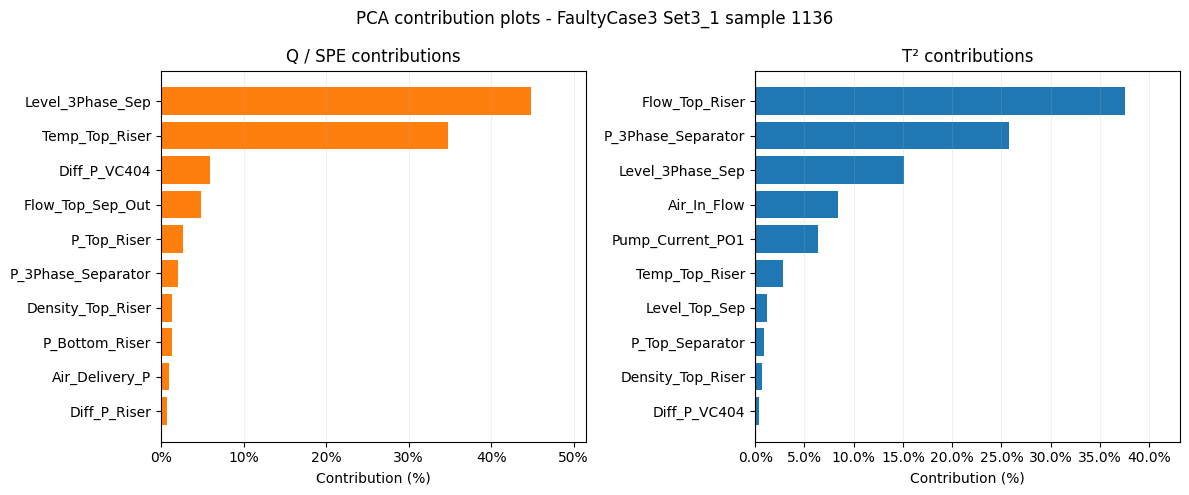

DPCA contribution sample: FaultyCase3 Set3_1, index 1136


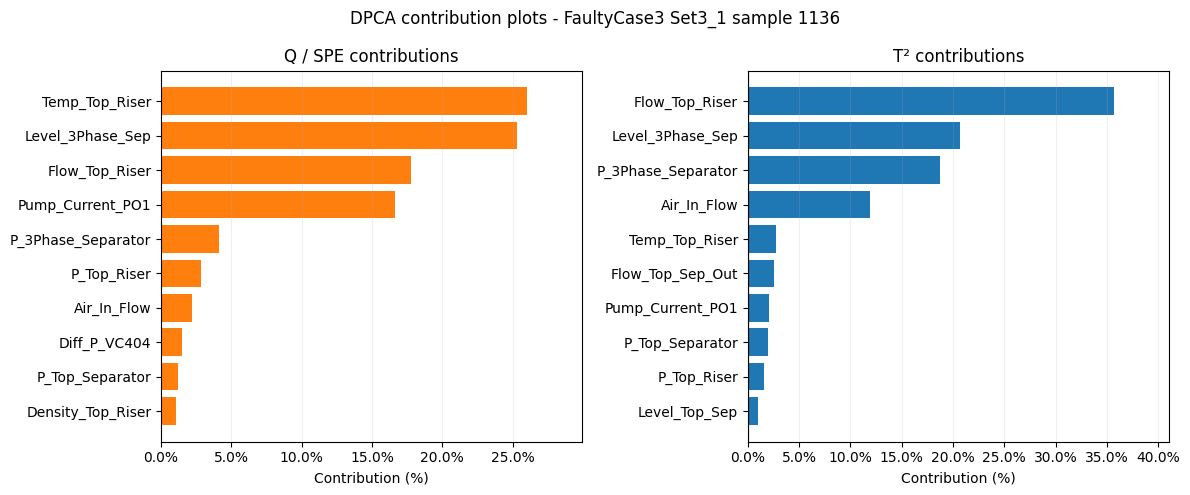

PCA contribution sample: FaultyCase5 Set5_2, index 1638


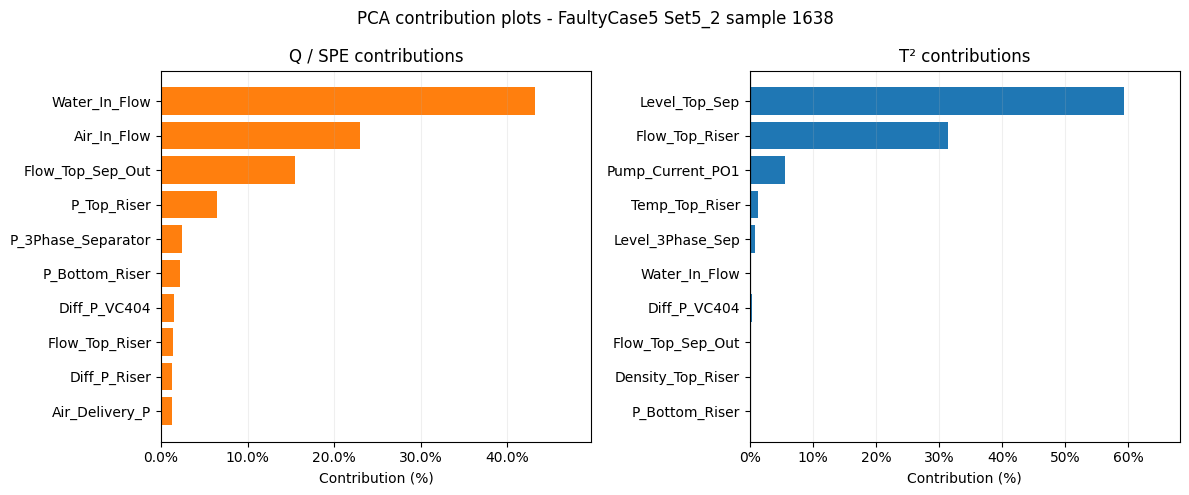

DPCA contribution sample: FaultyCase5 Set5_2, index 1641


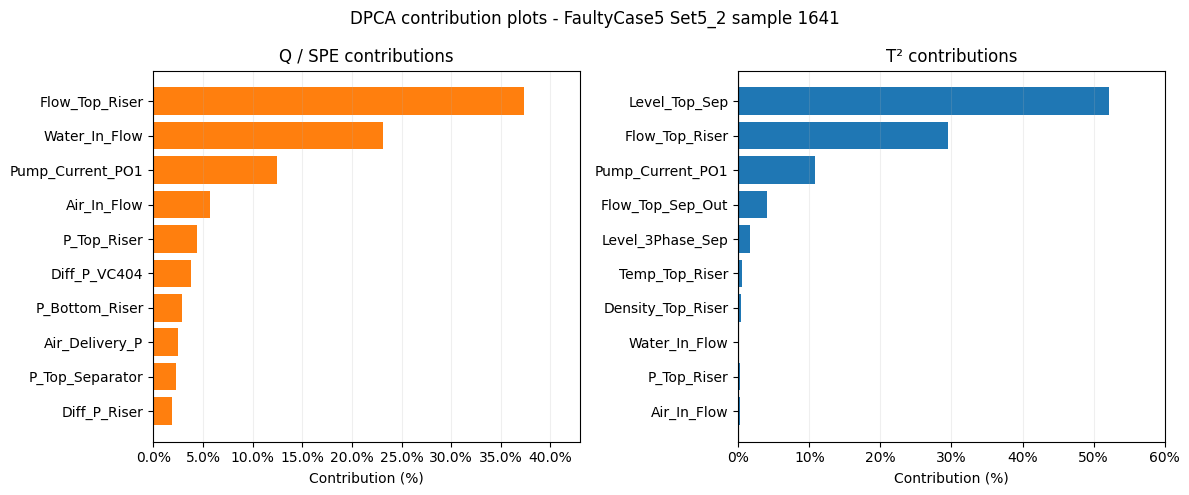

In [ ]:
# Contribution plots for PCA and DPCA: per-variable contributions to the Q and T² statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


selected_sets = [
    ("FaultyCase3", "Set3_1"),
    ("FaultyCase5", "Set5_2"),
]

case_to_index = {case_name: idx for idx, case_name in enumerate(se_windows.keys())}


def _first_alarm_or_fault_start(stat_series, threshold, windows):
    """Pick a diagnostic sample: first alarm after the first fault start, else the fault start."""
    first_fault_start = normalize_fault_windows(windows)[0][0]
    alarm_index = stat_series.index[stat_series > threshold]
    alarm_after_start = alarm_index[alarm_index >= first_fault_start]
    if len(alarm_after_start) > 0:
        return int(alarm_after_start[0])
    return int(first_fault_start)



def _pca_t2_contributions(x_row, score_row, model):
    """Per-variable T² contributions that sum to the Hotelling T² value."""
    x_values = x_row.to_numpy(dtype=float)
    t_values = score_row.to_numpy(dtype=float)
    loadings = np.asarray(model["projection_matrix"], dtype=float)
    eigenvalues = np.asarray(model["eigenvalues"][: model["n_components"]], dtype=float)

    t2_weighted_scores = t_values / eigenvalues
    contributions = x_values * (loadings @ t2_weighted_scores)

    return pd.Series(contributions, index=x_row.index, name="T2 contribution")



def _pca_q_contributions(x_row, score_row, model):
    """Per-variable Q/SPE contributions from the PCA reconstruction residual."""
    loadings = np.asarray(model["projection_matrix"], dtype=float)
    x_values = x_row.to_numpy(dtype=float)
    t_values = score_row.to_numpy(dtype=float)
    x_hat = t_values @ loadings.T
    residual = x_values - x_hat

    return pd.Series(residual ** 2, index=x_row.index, name="Q contribution")



def _aggregate_dpca_contributions(contributions):
    """Aggregate lagged-variable contributions back to the original sensor names."""
    aggregated = {}
    for name, value in contributions.items():
        sensor_name = name.rsplit("_t", 1)[0]
        aggregated[sensor_name] = aggregated.get(sensor_name, 0.0) + float(value)
    return pd.Series(aggregated).sort_values(ascending=False)



def _to_percent_share(series):
    """Convert a contribution series to percentage share of total absolute contribution."""
    total = float(series.abs().sum())
    if total == 0:
        return series * 0.0
    return series / total * 100.0



def _plot_contribution_pair(t2_contrib, q_contrib, title):
    top_t2 = t2_contrib.reindex(t2_contrib.abs().sort_values(ascending=False).head(10).index)
    top_q = q_contrib.sort_values(ascending=False).head(10)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].barh(top_q.index[::-1], top_q.values[::-1], color="tab:orange")
    axes[0].set_title("Q / SPE contributions")
    axes[0].set_xlabel("Contribution (%)")
    axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=100))
    axes[0].set_xlim(0, max(top_q.max() * 1.15, 1e-9))
    axes[0].grid(True, axis="x", alpha=0.2)

    axes[1].barh(top_t2.index[::-1], top_t2.values[::-1], color="tab:blue")
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_title("T² contributions")
    axes[1].set_xlabel("Contribution (%)")
    axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=100))
    max_abs_t2 = float(np.max(np.abs(top_t2.values))) if len(top_t2) > 0 else 0.0
    axes[1].set_xlim(0, max_abs_t2 * 1.15 if max_abs_t2 > 0 else 1)
    axes[1].grid(True, axis="x", alpha=0.2)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for case_name, set_name in selected_sets:
    case_idx = case_to_index[case_name]
    windows = se_windows[case_name][set_name]
    X_fault = fc_sets[case_idx][set_name].sensors

    # PCA contribution plots
    PCA_Z = pca_transform(X_fault, pca_model)
    PCA_q = q_statistic(X_fault, PCA_Z, pca_model)
    PCA_t2 = t2_statistic(PCA_Z, pca_model)
    pca_sample_index = _first_alarm_or_fault_start(PCA_q, threshold_q_pca, windows)
    pca_x_row = X_fault.loc[pca_sample_index]
    pca_score_row = PCA_Z.loc[pca_sample_index]

    pca_t2_contrib = _to_percent_share(_pca_t2_contributions(pca_x_row, pca_score_row, pca_model))
    pca_q_contrib = _to_percent_share(_pca_q_contributions(pca_x_row, pca_score_row, pca_model))

    print(f"PCA contribution sample: {case_name} {set_name}, index {pca_sample_index}")
    _plot_contribution_pair(
        pca_t2_contrib,
        pca_q_contrib,
        f"PCA contribution plots - {case_name} {set_name} sample {pca_sample_index}",
    )

    # DPCA contribution plots
    DPCA_lagged = dpca_prepare_matrix(X_fault, dpca_model)
    DPCA_Z = dpca_transform(X_fault, dpca_model)
    DPCA_q = q_statistic(DPCA_lagged, DPCA_Z, dpca_model["pca_model"])
    DPCA_t2 = t2_statistic(DPCA_Z, dpca_model["pca_model"])
    dpca_sample_index = _first_alarm_or_fault_start(DPCA_q, threshold_q_dpca, windows)
    dpca_x_row = DPCA_lagged.loc[dpca_sample_index]
    dpca_score_row = DPCA_Z.loc[dpca_sample_index]

    dpca_t2_contrib = _to_percent_share(
        _aggregate_dpca_contributions(
            _pca_t2_contributions(dpca_x_row, dpca_score_row, dpca_model["pca_model"])
        )
    )
    dpca_q_contrib = _to_percent_share(
        _aggregate_dpca_contributions(
            _pca_q_contributions(dpca_x_row, dpca_score_row, dpca_model["pca_model"])
        )
    )

    print(f"DPCA contribution sample: {case_name} {set_name}, index {dpca_sample_index}")
    _plot_contribution_pair(
        dpca_t2_contrib,
        dpca_q_contrib,
        f"DPCA contribution plots - {case_name} {set_name} sample {dpca_sample_index}",
    )


The index is the sample number from the faulty set’s time series that is chosen as the diagnostic point. It is picked by *_first_alarm_or_fault_start*: it uses the first alarm at or after the first fault start, and if there is no alarm it falls back to the fault start itself.